# Macroeconometrics and Machine Learning Project

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime
import scipy.stats
import sklearn as sk
import statsmodels.api as sm
from src.data_preprocessing import adf_reg, sequential_procedure, stationarity_test, transform_data, remove_outlier 
from src.exploratory_analysis import detect_outliers_iqr, lead_corr, plot_top_corrs
from src.model import EM_PCAResult, EM_PCA, RollingRegression, RollingRegressionResult
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data preprocessing

In [22]:
data:pd.DataFrame = pd.read_excel("data/BDD.xlsx", "Database")
data.set_index("Time", drop = True, inplace=True)
display(data.head())
print(f"Number of observations: {data.shape[0]} \nNumber of features {data.shape[1]}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print("Type of the data:\n", data.dtypes)

,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-01-01,9.4000,100.3497,0.9791,3.3431,3.5563,5.6700,84.7000,78.9000,82.8000,122.0000,77.9000,94.9000,111.8000,61.6000,60.9000,87.3000,62.7000,65.1000,67.3000,92.8715,77.8097,77.3402,80.8360,70.6480,47.9490,75.4485,79.8617,77.0934,81.3987,73.3043,59.0541,2.3000,-1.8000,115.1000,-3.5000,-6.8000,30.8000,101.4797,102.4122,338252.0000,1986266.0000,4121606.0000,112.9507,1053429.7000,NaN,0.0897,0.1118,0.1563,0.1498,0.0025,0.0079,-0.0057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.5100
2000-02-01,9.4000,98.8671,0.9714,3.5368,3.7347,5.6400,85.9000,79.9000,84.6000,124.7000,79.7000,96.6000,110.9000,62.8000,61.7000,90.8000,64.3000,66.3000,74.6000,92.9323,77.8872,77.4958,80.8384,70.7897,48.1935,75.5789,79.9039,77.2484,81.5434,73.3992,59.1088,4.1000,-1.9000,117.9000,-3.4000,1.9000,34.1000,101.6907,102.4543,338177.0000,1987628.0000,4136412.0000,121.7777,1044617.5000,NaN,0.0152,-0.0059,-0.0658,-0.0531,-0.0009,0.0090,-0.0026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.7800
2000-03-01,9.3000,97.2248,0.9553,3.7470,3.9362,5.4700,86.3000,80.4000,84.7000,122.7000,79.9000,97.0000,111.2000,63.5000,62.2000,90.7000,64.1000,67.1000,74.5000,92.7573,77.9184,77.4927,80.7715,70.9371,48.6612,75.7439,79.9437,77.5112,82.0052,73.4219,59.8210,5.8000,-1.8000,118.7000,-1.1000,-4.6000,35.1000,101.8916,102.4501,338104.0000,2003675.0000,4149339.0000,126.9063,1027773.7000,NaN,0.0210,-0.0246,-0.0131,-0.0399,-0.0007,-0.0350,-0.0029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.4900
2000-04-01,9.2000,95.7244,0.9085,3.9253,4.0827,5.3600,87.1000,81.5000,85.9000,125.6000,80.9000,97.0000,111.5000,64.0000,63.2000,91.9000,65.5000,67.7000,69.9000,92.8228,77.9791,77.5027,80.9426,71.3095,48.3710,75.7305,79.9940,77.4408,81.8123,73.4918,59.0646,5.6000,-2.2000,116.9000,-1.7000,-1.2000,29.7000,102.0225,102.4045,338077.0000,2022293.0000,4174322.0000,120.3200,1017495.4000,NaN,0.0010,-0.0420,0.0092,-0.0704,-0.0083,-0.0047,-0.0091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.7600
2000-05-01,9.1000,93.8781,0.9303,4.3620,4.5439,5.5300,88.5000,83.0000,87.0000,128.2000,81.9000,99.3000,110.4000,65.3000,64.6000,93.5000,65.6000,68.9000,73.5000,92.8854,78.2185,77.8034,80.8804,71.6153,49.1761,75.8369,80.0191,77.6101,82.0638,73.5064,59.4754,6.7000,-1.9000,118.2000,-0.2000,2.6000,31.0000,102.1219,102.3452,339633.0000,2005841.0000,4168507.0000,120.5504,1057067.4000,NaN,0.0032,-0.0302,0.0269,-0.0101,-0.0049,0.0106,0.0025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.7400


Number of observations: 310 
Number of features 61
Date range: 2000-01-01 00:00:00 to 2025-10-01 00:00:00
Type of the data:
 UNETOT_EA      float64
REER42_EA      float64
ERUS_EA        float64
IRT3M_EACC     float64
IRT6M_EACC     float64
LTIRT_EACC     float64
IPMN_EA        float64
IPCAG_EA       float64
IPCOG_EA       float64
IPDCOG_EA      float64
IPNDCOG_EA     float64
IPING_EA       float64
IPNRG_EA       float64
TRNMN_EA       float64
TRNCAG_EA      float64
TRNDCOG_EA     float64
TRNNDCOG_EA    float64
TRNING_EA      float64
TRNNRG_EA      float64
PPICAG_EA      float64
PPICOG_EA      float64
PPINDCOG_EA    float64
PPIDCOG_EA     float64
PPIING_EA      float64
PPINRG_EA      float64
HICPOV_EA      float64
HICPNEF_EA     float64
HICPG_EA       float64
HICPIN_EA      float64
HICPSV_EA      float64
HICPNG_EA      float64
ICONFIX_EA     float64
CCONFIX_EA     float64
ESENTIX_EA     float64
KCONFIX_EA     float64
RTCONFIX_EA    float64
SCONFIX_EA     float64
BCI_EA         float64
C

In [23]:
# Keep only dates for which financial variables are available
data = data.loc["2004-09-01":"2025-01-01"]
print("Descriptive statistics\n")
display(data.describe())
print('Number of missing values per feature:', data.isna().sum())

Descriptive statistics



,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
count,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,215.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000,245.0000
mean,9.0118,108.6569,1.2304,1.2064,1.3290,2.4954,94.9943,95.1873,93.0196,99.1314,92.2959,97.2959,108.7739,91.0192,91.6845,91.4873,90.6408,88.5792,115.0751,97.6763,96.8153,96.9773,95.1387,92.1589,92.4862,100.7439,99.9940,101.5745,101.7218,99.5454,104.7728,-3.4273,-12.3873,99.6702,-10.5437,-5.3298,5.7208,100.2732,99.5355,1000933.6857,6681313.3878,10311211.0367,97.4555,836596.1478,0.0012,0.0033,0.0072,0.0013,0.0021,-0.0009,0.0003,0.0004,0.9899,1.3633,2.0571,-1.2365,10.8668,-10.2067,3.5376,3.5846,75.5972
std,1.7367,4.8119,0.1334,1.7010,1.7030,1.5046,5.5951,8.2645,6.6212,9.8689,7.3621,6.6366,9.6990,13.1843,14.7383,10.6625,15.4746,11.7699,25.0197,6.2649,9.9361,10.0242,8.3973,12.1370,30.1237,11.1703,8.4577,11.7082,9.8870,10.4497,22.6013,9.4178,5.5154,10.1473,13.0411,7.0892,10.6960,1.7278,1.4985,331995.2804,2725848.0047,2975941.9157,21.6764,122493.4310,0.0518,0.0481,0.0516,0.0596,0.0556,0.0061,0.0137,0.0075,1.6195,1.5883,1.5676,1.4951,9.4082,10.2824,2.9204,3.1438,24.2065
min,6.2000,96.3651,0.9748,-0.5820,-0.5446,-0.2200,69.4000,60.7000,78.8000,48.2000,82.9000,72.9000,89.7000,65.1000,56.8000,47.5000,70.9000,65.8000,45.7000,91.1128,83.7606,83.6400,84.9020,75.6959,56.1757,83.3561,86.6933,84.3907,87.1368,82.0309,68.3947,-37.1000,-28.8000,58.5000,-34.8000,-35.9000,-51.8000,94.2818,95.3588,439851.0000,2868123.0000,5484081.0000,51.8287,170697.1000,-0.1779,-0.1889,-0.2131,-0.2541,-0.2512,-0.0411,-0.0806,-0.0159,-0.9297,-0.9163,0.0100,-4.9595,-11.0434,-28.5977,0.2500,0.3151,18.3800
25%,7.6000,105.4582,1.1151,-0.3105,-0.2227,1.0700,91.4000,90.3000,88.0000,92.8000,86.8000,93.6000,102.2000,84.4000,80.9000,83.0000,80.1000,81.6000,98.5000,92.5076,89.8007,89.8519,89.1952,85.5138,74.6819,92.0418,93.6408,93.1946,95.1788,91.7182,89.9488,-8.3000,-16.2000,95.0000,-24.1000,-9.7000,2.2000,99.3713,98.5035,747082.0000,4448680.0000,8189516.0000,78.6491,747340.7000,-0.0301,-0.0246,-0.0211,-0.0325,-0.0247,-0.0027,-0.0060,-0.0047,-0.5822,-0.2324,0.8794,-2.2381,1.8522,-20.5588,1.4161,1.8774,57.3600
50%,8.8000,108.5112,1.2118,0.6447,0.9345,3.0000,95.7000,96.9000,91.3000,96.9000,89.7000,96.8000,108.9000,87.3000,87.9000,88.8000,85.6000,85.9000,113.4000,96.4034,95.4059,95.7108,93.2348,89.3626,82.5948,99.8314,99.1921,100.4906,100.4891,98.9129,101.0431,-2.5000,-12.3000,100.1000,-8.5000,-4.0000,7.8000,100.4601,99.5579,958592.0000,5788176.0000,9559214.0000,98.6153,847148.7000,0.0072,0.0091,0.0145,0.0076,0.0067,-0.0003,0.0020,-0.0004,0.3578,1.1719,1.6055,-1.4557,11.7709,-8.7553,2.3972,2.4622,73.6700
75%,10.3000,111.1244,1.3308,2.4565,2.6003,3.8300,99.5000,101.7000,96.0000,102.5000,95.8000,100.8000,116.7000,96.7000,102.5000,99.7000,95.2000,92.0000,130.6000,98.8830,98.1086,98.1980,96.8008,92.0138,92.6704,104.9694,104.4542,104.2259,102.7409,106.3106,109.0569,3.2000,-7.7000,105.8000,1.4000,-0.1000,12.7000,101.4906,100.8737,1224324.0000,8950015.0000,12381853.0000,111.6844,940780

Number of missing values per feature: UNETOT_EA       0
REER42_EA       0
ERUS_EA         0
IRT3M_EACC      0
IRT6M_EACC      0
LTIRT_EACC      0
IPMN_EA         0
IPCAG_EA        0
IPCOG_EA        0
IPDCOG_EA       0
IPNDCOG_EA      0
IPING_EA        0
IPNRG_EA        0
TRNMN_EA        0
TRNCAG_EA       0
TRNDCOG_EA      0
TRNNDCOG_EA     0
TRNING_EA       0
TRNNRG_EA       0
PPICAG_EA       0
PPICOG_EA       0
PPINDCOG_EA     0
PPIDCOG_EA      0
PPIING_EA       0
PPINRG_EA       0
HICPOV_EA       0
HICPNEF_EA      0
HICPG_EA        0
HICPIN_EA       0
HICPSV_EA       0
HICPNG_EA       0
ICONFIX_EA      0
CCONFIX_EA      0
ESENTIX_EA      0
KCONFIX_EA      0
RTCONFIX_EA     0
SCONFIX_EA      0
BCI_EA          0
CCI_EA          0
CURR_EACC       0
M1_EACC         0
M2_EACC         0
SHIX_EA         0
CAREG_EA        0
Eurostoxx      30
CAC 40          0
DAX             0
FTSE MIB        0
ES35            0
Forex Swiss     0
Forex Japan     0
Forex UK        0
2 ans ZC        0
5 ans ZC

In [24]:
# We distinguish between EA-MD data and financial variables
eurostoxx_index:int = data.columns.get_loc("Eurostoxx")

# For now, we forward fill, but we will use EM when computing factors
df_ea_md:pd.DataFrame = data.iloc[:, :eurostoxx_index].ffill()
df_fi: pd.DataFrame = data.iloc[:, eurostoxx_index:np.shape(data)[1]].ffill()

In [25]:
# Stationarity test for all the EA-MD series in our dataset
statio_list: list = stationarity_test(df_ea_md)
print(statio_list)

                  UNETOT_EA REER42_EA       ERUS_EA IRT3M_EACC IRT6M_EACC  \
Integration Order      I(1)  I(1) + C  I(1) + C + T       I(1)       I(1)   

                  LTIRT_EACC   IPMN_EA  IPCAG_EA      IPCOG_EA IPDCOG_EA  \
Integration Order       I(1)  I(1) + C  I(1) + C  I(1) + C + T  I(1) + C   

                     IPNDCOG_EA  IPING_EA      IPNRG_EA      TRNMN_EA  \
Integration Order  I(1) + C + T  I(1) + C  I(0) + C + T  I(1) + C + T   

                      TRNCAG_EA TRNDCOG_EA TRNNDCOG_EA TRNING_EA TRNNRG_EA  \
Integration Order  I(1) + C + T       I(1)        I(1)      I(1)  I(0) + C   

                  PPICAG_EA PPICOG_EA PPINDCOG_EA    PPIDCOG_EA     PPIING_EA  \
Integration Order      I(1)      I(1)        I(1)  I(1) + C + T  I(1) + C + T   

                  PPINRG_EA     HICPOV_EA HICPNEF_EA      HICPG_EA  \
Integration Order      I(1)  I(1) + C + T       I(1)  I(1) + C + T   

                      HICPIN_EA HICPSV_EA     HICPNG_EA ICONFIX_EA CCONFIX_EA  \
Int

In [26]:
# We apply the EA-MD recommended corrections for all series and perform the sequential procedure again
df_code_transfo: pd.DataFrame = pd.read_excel("data/BDD.xlsx","Transformations EA-MD")

# We apply the Heavy transformations by default (no prior on the integration degree)
list_transfo_features: list = df_code_transfo.iloc[1,1:np.shape(df_code_transfo)[1]]
df_macro_transfo: pd.DataFrame = df_ea_md.copy()

# Loop to build the transformed dataset
for i in range(df_ea_md.shape[1]):
    # Retrieve the feature
    feature = df_ea_md.iloc[:, i]

    # Perform the appropriate transformation
    code:int = list_transfo_features[i]
    feature_transfo = transform_data(feature, code = code)
    df_macro_transfo.iloc[:,i] = feature_transfo


statio_list_post_transfo:list = stationarity_test(df_macro_transfo)
print(statio_list_post_transfo)

                  UNETOT_EA REER42_EA ERUS_EA IRT3M_EACC IRT6M_EACC  \
Integration Order      I(0)      I(0)    I(0)       I(0)       I(0)   

                  LTIRT_EACC IPMN_EA IPCAG_EA IPCOG_EA IPDCOG_EA IPNDCOG_EA  \
Integration Order       I(0)    I(0)     I(0)     I(0)      I(0)       I(0)   

                  IPING_EA  IPNRG_EA TRNMN_EA TRNCAG_EA TRNDCOG_EA  \
Integration Order     I(0)  I(0) + C     I(0)      I(0)       I(0)   

                  TRNNDCOG_EA TRNING_EA TRNNRG_EA PPICAG_EA PPICOG_EA  \
Integration Order    I(0) + C      I(0)      I(0)      I(0)      I(0)   

                  PPINDCOG_EA PPIDCOG_EA PPIING_EA PPINRG_EA HICPOV_EA  \
Integration Order        I(0)       I(0)      I(0)      I(0)      I(0)   

                  HICPNEF_EA HICPG_EA HICPIN_EA HICPSV_EA HICPNG_EA  \
Integration Order       I(0)     I(0)      I(0)      I(0)      I(0)   

                  ICONFIX_EA CCONFIX_EA ESENTIX_EA KCONFIX_EA RTCONFIX_EA  \
Integration Order       I(0)   I(0) + C  

In [27]:
# Similar analysis for financial series
statio_list_varfi = stationarity_test(df_fi)
print("Financial variables before treatment\n")
display(statio_list_varfi)

# For all series which are not I(0), we perform a differenciation at first order
df_fi_transfo = df_fi.copy()

for i in range(df_fi.shape[1]):
    # Retrieve the feature
    feature = df_fi.iloc[:, i]
    
    integration_type = statio_list_varfi.iloc[0, i]
    
    if integration_type in ["I(0) + C + T", "I(0) + C", "I(0)"]:
        code = 0
    else:
        code = 4
        
    feature_transfo = transform_data(feature, code=code)
    df_fi_transfo.iloc[:, i] = feature_transfo

statio_list_fi_post_transfo = stationarity_test(df_fi_transfo)
print("Financial variables after treatment\n")
display(statio_list_fi_post_transfo)

Financial variables before treatment



,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Integration Order,I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(1),I(1),I(1) + C + T,I(1),I(1),I(1),I(0) + C,I(1) + C,I(0) + C


Financial variables after treatment



,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Integration Order,I(0),I(0),I(0) + C,I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0),I(0) + C,I(0),I(0) + C


In [28]:
# We concatenate the dataframe with all stationarity treatment performed
df_final: pd.DataFrame = pd.concat([df_macro_transfo, df_fi_transfo], axis=1)
# Some variables have been first differenciated, so we loose the first date
df_final = df_final.iloc[1:,:]
display(df_final.head())
display(df_final.describe())

,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-10-01,0.0000,1.2856,2.6089,0.0287,-0.0097,-0.1200,0.6652,1.5285,-0.2307,-0.2685,-0.2389,0.5935,-0.6606,0.5540,2.2316,-0.3365,-0.2797,0.4008,4.5359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.2000,-11.6000,0.2000,-11.5000,-10.8000,7.9000,100.4276,99.6988,NaN,NaN,NaN,1.6214,3.1428,NaN,0.0126,0.0410,0.0320,0.0321,-0.0001,-0.0065,0.0064,-0.1392,-0.1814,-0.0016,0.0920,-0.1108,-0.3498,3.5142,-0.6138,49.7800
2004-11-01,0.0000,0.9797,4.2877,0.0230,0.0267,-0.1200,-1.4469,-2.8404,-0.2312,-2.5410,0.1195,-0.6927,0.6606,0.0000,-3.5091,0.0000,0.6978,-0.2670,4.0201,-0.0023,0.0016,0.0008,0.0014,-0.0017,-0.0358,-0.0028,0.0006,-0.0055,-0.0088,0.0009,-0.0248,-3.2000,-12.1000,-1.2000,-11.5000,-13.5000,7.8000,100.3679,99.7144,-0.0014,0.0017,-0.0017,3.1007,-0.2490,NaN,0.0178,0.0310,0.0426,0.0436,-0.0060,0.0045,0.0045,-0.0804,-0.0922,-0.3004,0.3682,0.3802,-0.8761,2.9694,-0.0372,43.1100
2004-12-01,0.0000,1.4250,2.4225,0.0029,-0.0108,-0.2100,-0.2245,-0.3608,1.3793,0.4585,1.5412,-0.3980,0.7380,0.0000,-0.1430,-0.7896,0.4164,-0.8054,-3.4673,0.0005,0.0002,-0.0005,-0.0007,-0.0029,-0.0040,0.0011,0.0001,0.0017,-0.0016,0.0004,-0.0109,-3.3000,-11.7000,-0.3000,-10.0000,-10.3000,5.8000,100.2738,99.7897,0.0022,-0.0111,0.0011,1.8475,0.7884,NaN,0.0239,-0.0003,0.0139,0.0156,0.0042,0.0098,-0.0023,0.1031,0.0057,-0.0763,-0.0252,0.0093,0.7124,3.2933,1.1787,39.6000
2005-01-01,-0.1000,-1.9976,-4.3975,-0.0278,-0.0145,-0.0500,2.1124,2.7334,-1.0327,1.4532,-1.5412,2.1697,-3.3226,1.3718,3.5141,2.1289,-1.8170,2.2653,3.2541,0.0040,0.0025,0.0028,0.0050,0.0034,0.0265,-0.0005,-0.0005,-0.0004,0.0044,-0.0006,0.0016,-4.1000,-11.0000,1.1000,-10.6000,-9.8000,9.6000,100.1203,99.9020,-0.0002,0.0222,0.0033,1.7145,-0.7081,NaN,0.0286,0.0222,0.0163,0.0180,0.0030,-0.0148,0.0023,-0.0851,-0.1092,-0.4074,0.4195,0.2843,-0.0157,3.2969,-0.8124,44.5100
2005-02-01,0.0000,-0.9478,1.6888,-0.0070,-0.0074,-0.0100,-1.3289,-1.0607,0.3454,-0.1805,0.3578,-2.0701,3.3226,-1.2337,-1.6713,-0.1109,0.8427,-1.5937,0.0000,-0.0036,-0.0025,-0.0016,-0.0049,-0.0040,-0.0080,0.0016,-0.0005,0.0031,0.0019,-0.0005,0.0173,-5.1000,-10.6000,-1.2000,-10.1000,-11.3000,6.8000,99.9059,99.9647,-0.0038,-0.0108,-0.0036,3.4879,-2.9449,NaN,0.0100,-0.0004,0.0141,-0.0142,0.0009,0.0098,-0.0056,0.1002,0.1564,0.0663,-0.0905,0.4193,0.2417,3.5448,-0.0012,45.4800


,UNETOT_EA,REER42_EA,ERUS_EA,IRT3M_EACC,IRT6M_EACC,LTIRT_EACC,IPMN_EA,IPCAG_EA,IPCOG_EA,IPDCOG_EA,IPNDCOG_EA,IPING_EA,IPNRG_EA,TRNMN_EA,TRNCAG_EA,TRNDCOG_EA,TRNNDCOG_EA,TRNING_EA,TRNNRG_EA,PPICAG_EA,PPICOG_EA,PPINDCOG_EA,PPIDCOG_EA,PPIING_EA,PPINRG_EA,HICPOV_EA,HICPNEF_EA,HICPG_EA,HICPIN_EA,HICPSV_EA,HICPNG_EA,ICONFIX_EA,CCONFIX_EA,ESENTIX_EA,KCONFIX_EA,RTCONFIX_EA,SCONFIX_EA,BCI_EA,CCI_EA,CURR_EACC,M1_EACC,M2_EACC,SHIX_EA,CAREG_EA,Eurostoxx,CAC 40,DAX,FTSE MIB,ES35,Forex Swiss,Forex Japan,Forex UK,2 ans ZC,5 ans ZC,Beta 0,Beta 1,Beta 2,Beta3,Tau1,Tau2,Brent
count,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,243.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,243.0000,243.0000,243.0000,244.0000,244.0000,215.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000
mean,-0.0127,-0.0207,-0.0727,0.0024,0.0017,-0.0043,0.0358,0.0683,0.0933,-0.0637,0.1145,-0.0543,-0.1144,0.1955,0.2021,0.0675,0.2526,0.1388,0.1497,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0001,-3.4303,-12.3902,-0.0221,-10.5324,-5.3094,5.7090,100.2726,99.5349,-0.0001,-0.0000,-0.0000,0.3052,-0.0951,0.0012,0.0032,0.0071,0.0012,0.0019,-0.0009,0.0003,0.0004,-0.0022,-0.0046,-0.0170,0.0198,0.0010,0.0235,3.5392,0.0376,75.7300
std,0.1094,1.2772,2.6392,0.1512,0.1524,0.1716,2.3642,3.7952,2.0517,4.7809,2.0585,2.1169,2.2966,2.6040,4.1384,4.6666,1.9131,2.2460,5.9910,0.0032,0.0025,0.0026,0.0020,0.0035,0.0257,0.0028,0.0016,0.0046,0.0070,0.0017,0.0186,9.4370,5.5265,3.1572,13.0667,7.0966,10.7164,1.7313,1.5015,0.0060,0.0077,0.0040,4.4544,12.0260,0.0518,0.0482,0.0517,0.0597,0.0557,0.0062,0.0137,0.0075,0.1949,0.2018,0.6185,0.7005,3.7571,3.9877,2.9263,1.1912,24.1667
min,-0.3000,-4.9582,-11.4389,-0.9457,-0.9295,-0.5300,-22.0258,-31.6505,-14.7238,-40.6847,-12.5375,-18.7111,-11.8497,-26.3191,-39.7215,-43.1099,-13.2183,-20.0394,-40.4735,-0.0095,-0.0090,-0.0091,-0.0073,-0.0172,-0.1042,-0.0166,-0.0094,-0.0291,-0.0488,-0.0054,-0.1205,-37.1000,-28.8000,-35.3000,-34.8000,-35.9000,-51.8000,94.2818,95.3588,-0.0532,-0.0502,-0.0153,-27.7384,-116.8069,-0.1779,-0.1889,-0.2131,-0.2541,-0.2512,-0.0411,-0.0806,-0.0159,-0.9108,-0.5542,-4.4037,-3.6241,-25.1507,-36.1398,0.2500,-4.9066,18.3800
25%,-0.1000,-0.7918,-1.6521,-0.0186,-0.0260,-0.1200,-0.6506,-1.2004,-0.9412,-1.3626,-1.0159,-0.7004,-1.3233,-0.5506,-1.0758,-1.0410,-0.5131,-0.5870,-2.1544,-0.0021,-0.0012,-0.0015,-0.0010,-0.0020,-0.0128,-0.0015,-0.0007,-0.0021,-0.0034,-0.0008,-0.0104,-8.3000,-16.2000,-0.8000,-24.1000,-9.5500,2.1500,99.3691,98.4960,-0.0019,-0.0035,-0.0021,-1.5508,-2.2364,-0.0301,-0.0248,-0.0211,-0.0328,-0.0248,-0.0027,-0.0061,-0.0047,-0.0831,-0.1270,-0.1532,-0.1478,-0.2636,-0.2463,1.4087,-0.2397,57.4725
50%,0.0000,-0.1049,-0.0539,-0.0008,-0.0017,-0.0250,0.2105,0.2044,0.1020,0.0000,0.1086,0.0000,0.0888,0.3911,0.3053,0.1232,0.2710,0.1171,0.2110,0.0002,0.0001,0.0000,0.0001,-0.0000,0.0004,0.0001,0.0000,-0.0000,0.0003,0.0001,-0.0002,-2.5000,-12.3500,0.1000,-8.0500,-3.9000,7.7500,100.4606,99.5533,-0.0001,0.0000,-0.0003,1.1046,-0.0008,0.0072,0.0089,0.0144,0.0075,0.0064,-0.0003,0.0019,-0.0004,-0.0051,-0.0263,-0.0075,0.0129,0.0032,0.0147,2.3887,0.0226,73.7100
75%,0.0000,0.7376,1.6880,0.0424,0.0440,0.0900,0.8294,1.5384,1.0982,1.2886,1.2237,0.7171,1.1577,1.0777,1.7306,1.1713,1.2343,1.0584,3.1762,0.0018,0.0014,0.0015,0.0009,0.0019,0.0130,0.0014,0.0007,0.0021,0.0033,0.0009,0.0111,3.2000,-7.6750,1.0000,1.4000,-0.1000,12.7250,101.4965,100.8835,0.0019,0.0033,0.0024,2.9656,2.9931,0.0369,0.0346,0.0392,0.0381,0.0317,0.0020,0.0078,0.0041,0.0826,0.1292,0.1456,0.2267,0.2561,0.2934,5.2958,0.2312,93.4275
max,0.4000,5.7307,8.9385,0.6162,0.7591,0.7600,13.8383,23.1347,8.0433,42.3286,6

## 2. Exploratory analysis

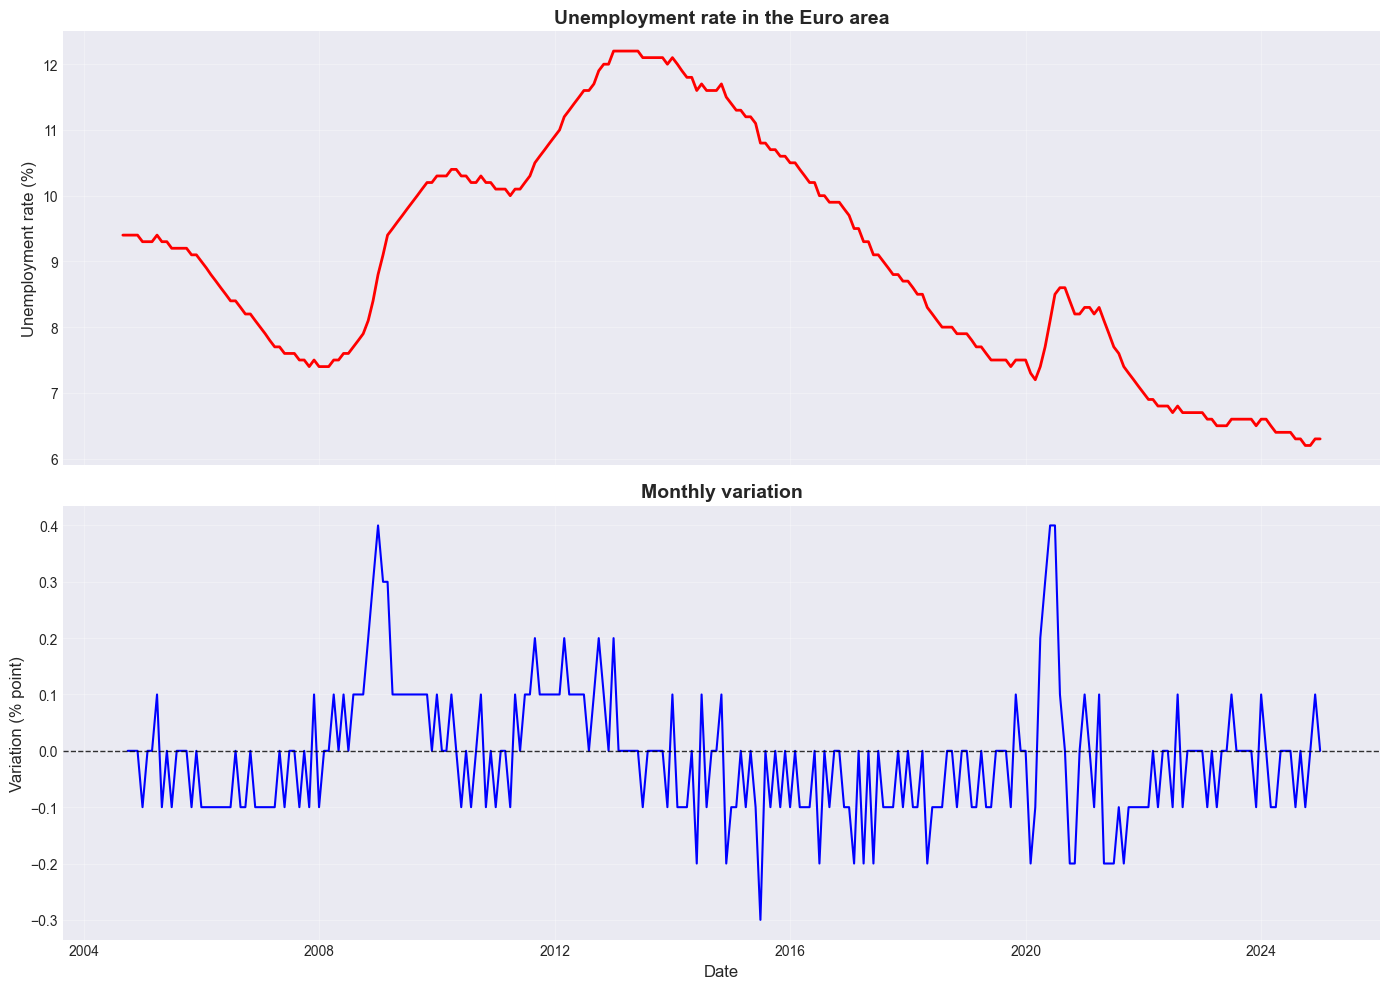

count   245.0000
mean      9.0118
std       1.7367
min       6.2000
25%       7.6000
50%       8.8000
75%      10.3000
max      12.2000
Name: UNETOT_EA, dtype: float64

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax1.plot(data.index, data['UNETOT_EA'], linewidth=2, color="r")
ax1.set_ylabel('Unemployment rate (%)', fontsize=12)
ax1.set_title('Unemployment rate in the Euro area', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Graphique 2 : La Variation (Changement d'un mois sur l'autre)
ax2.plot(df_final.index, df_final['UNETOT_EA'], linewidth=1.5, color="b")
ax2.set_ylabel('Variation (% point)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_title('Monthly variation', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Ajout d'une ligne horizontale à 0 pour bien voir les hausses/baisses
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.8)

plt.tight_layout()
plt.show()

display(data["UNETOT_EA"].describe())

Total missing values: 44
Columns with missing values: 16


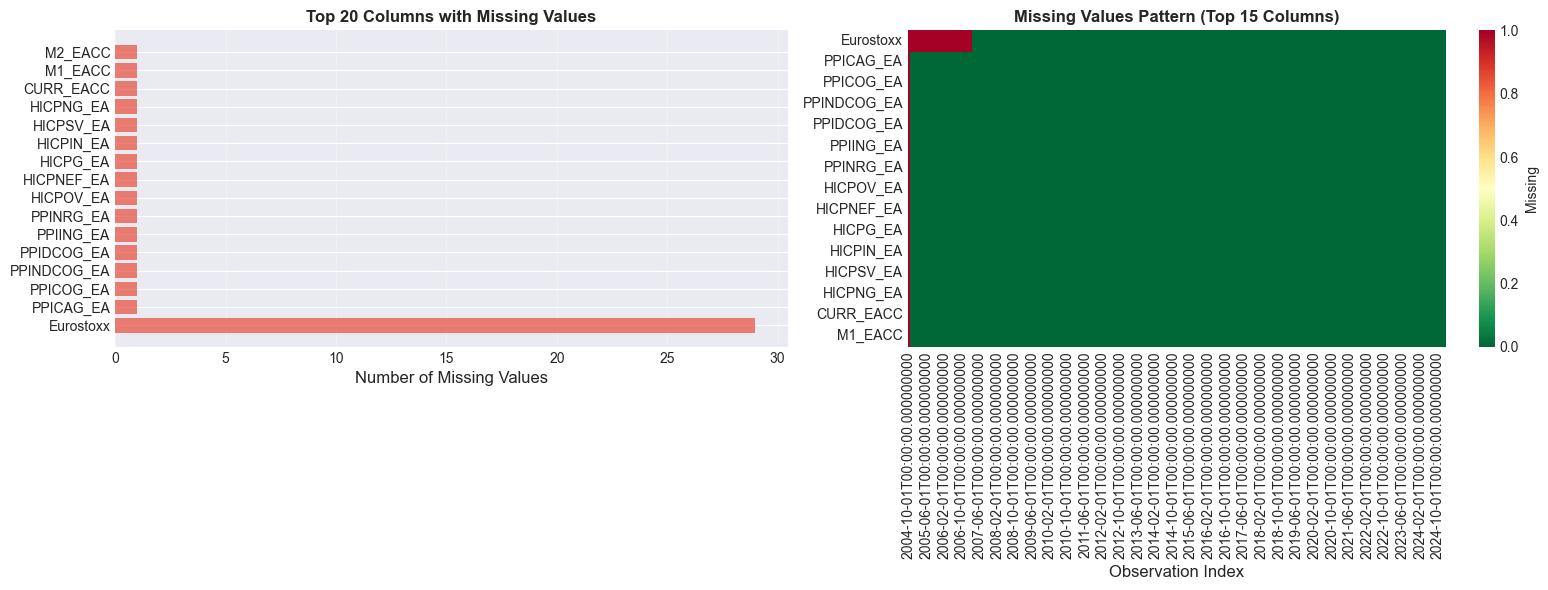

In [30]:
# Calculate missing values
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"Total missing values: {missing.sum()}")
print(f"Columns with missing values: {len(missing_df)}")

# Visualize missing values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of missing values
top_missing = missing_df.head(20)
ax1.barh(range(len(top_missing)), top_missing['Missing_Count'], color='#e74c3c', alpha=0.7)
ax1.set_yticks(range(len(top_missing)))
ax1.set_yticklabels(top_missing['Column'])
ax1.set_xlabel('Number of Missing Values', fontsize=12)
ax1.set_title('Top 20 Columns with Missing Values', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Heatmap of missing values pattern (sample)
# Select columns with missing values for visualization
cols_with_missing = missing_df['Column'].head(15).tolist()
missing_pattern = df_final[cols_with_missing].isnull().astype(int)
sns.heatmap(missing_pattern.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing'}, ax=ax2, yticklabels=True)
ax2.set_xlabel('Observation Index', fontsize=12)
ax2.set_title('Missing Values Pattern (Top 15 Columns)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Outlier Detection (IQR method):
  Lower bound: -0.25%
  Upper bound: 0.15%
  Number of outliers: 14

Outlier observations:
  2008-11: 0.20%
  2008-12: 0.30%
  2009-01: 0.40%
  2009-02: 0.30%
  2009-03: 0.30%
  2011-09: 0.20%
  2012-03: 0.20%
  2012-10: 0.20%
  2013-01: 0.20%
  2015-07: -0.30%
  2020-04: 0.20%
  2020-05: 0.30%
  2020-06: 0.40%
  2020-07: 0.40%


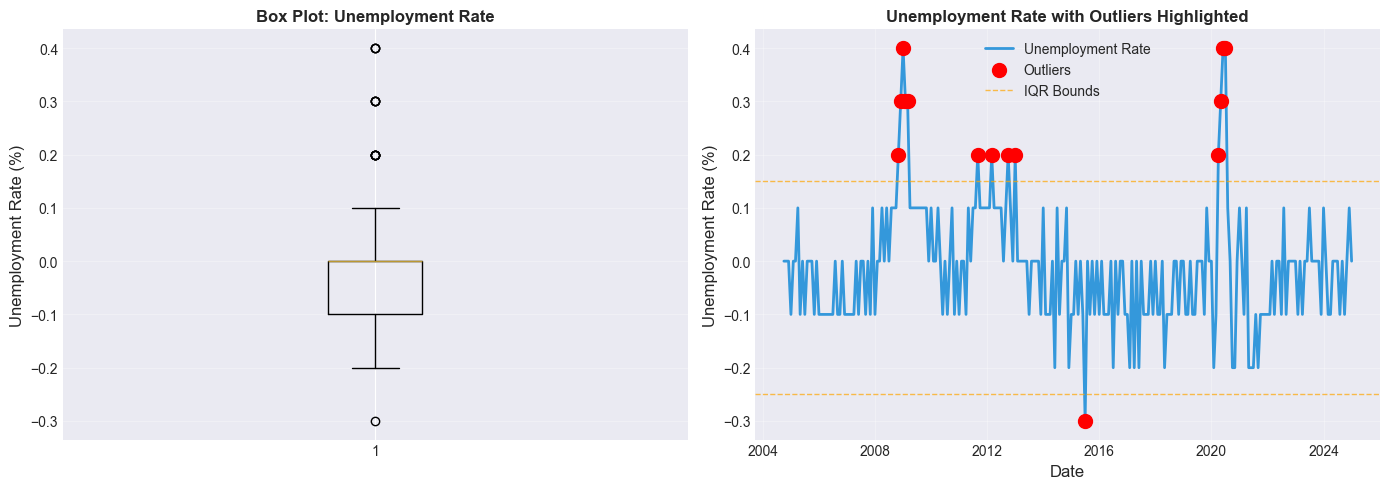

In [31]:
# Detect outliers using IQR method for unemployment rate
outliers, lower, upper = detect_outliers_iqr(df_final['UNETOT_EA'].dropna())
outlier_dates = df_final.index[outliers]
outlier_values = df_final.loc[outliers, 'UNETOT_EA']

print(f"Outlier Detection (IQR method):")
print(f"  Lower bound: {lower:.2f}%")
print(f"  Upper bound: {upper:.2f}%")
print(f"  Number of outliers: {outliers.sum()}")

if outliers.sum() > 0:
    print(f"\nOutlier observations:")
    for date, value in zip(outlier_dates, outlier_values):
        print(f"  {date.strftime('%Y-%m')}: {value:.2f}%")

        # Box plot for unemployment rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax1.boxplot(df_final['UNETOT_EA'].dropna(), vert=True)
ax1.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax1.set_title('Box Plot: Unemployment Rate', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Time series with outliers highlighted
ax2.plot(df_final.index, df_final['UNETOT_EA'], linewidth=2, color='#3498db', label='Unemployment Rate')
if outliers.sum() > 0:
    ax2.scatter(outlier_dates, outlier_values, color='red', s=100, zorder=5, label='Outliers')
ax2.axhline(lower, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='IQR Bounds')
ax2.axhline(upper, color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax2.set_title('Unemployment Rate with Outliers Highlighted', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

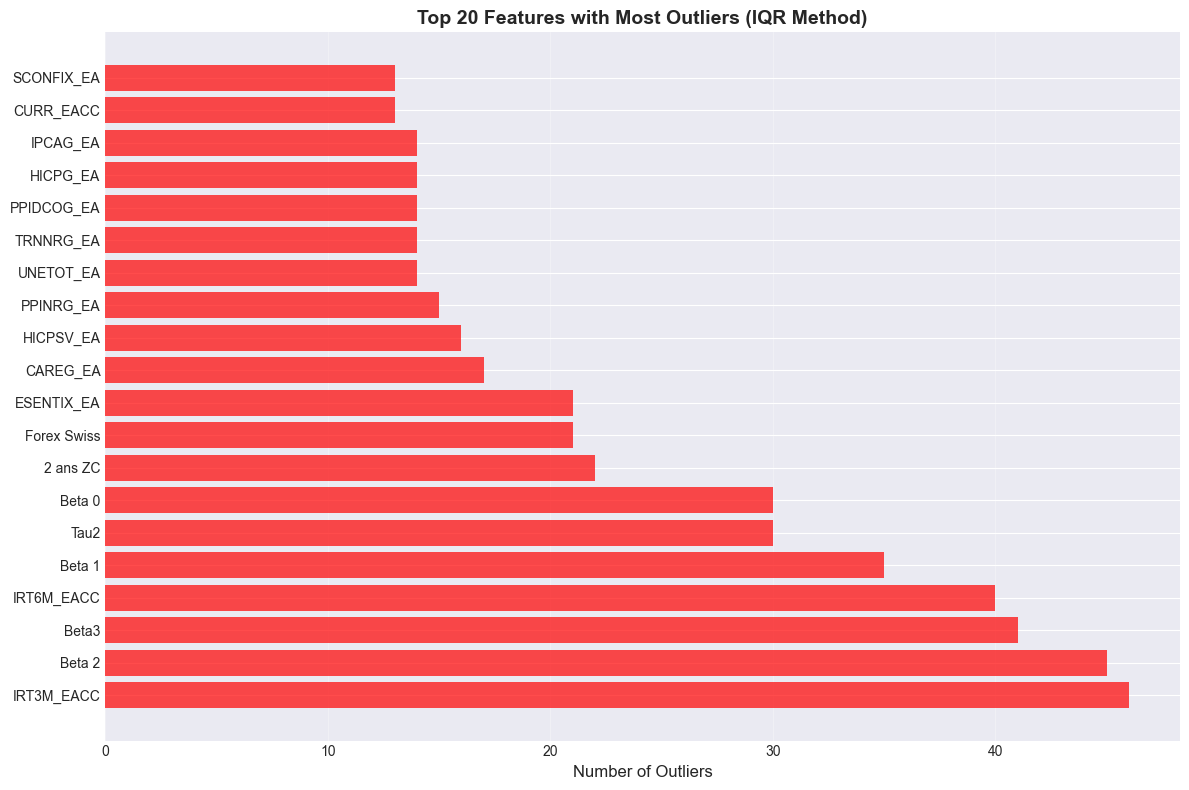

In [32]:
# Detect outliers across all numeric features
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {}

for col in numeric_cols:
    if df_final[col].notna().sum() > 10:  # Only if enough data
        outliers_col, _, _ = detect_outliers_iqr(df_final[col].dropna())
        outlier_counts[col] = outliers_col.sum()

outlier_df = pd.DataFrame({
    'Column': list(outlier_counts.keys()),
    'Outlier_Count': list(outlier_counts.values())
}).sort_values('Outlier_Count', ascending=False)

# Visualize outlier counts
fig, ax = plt.subplots(figsize=(12, 8))
top_outliers = outlier_df.head(20)
ax.barh(range(len(top_outliers)), top_outliers['Outlier_Count'], color='red', alpha=0.7)
ax.set_yticks(range(len(top_outliers)))
ax.set_yticklabels(top_outliers['Column'])
ax.set_xlabel('Number of Outliers', fontsize=12)
ax.set_title('Top 20 Features with Most Outliers (IQR Method)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

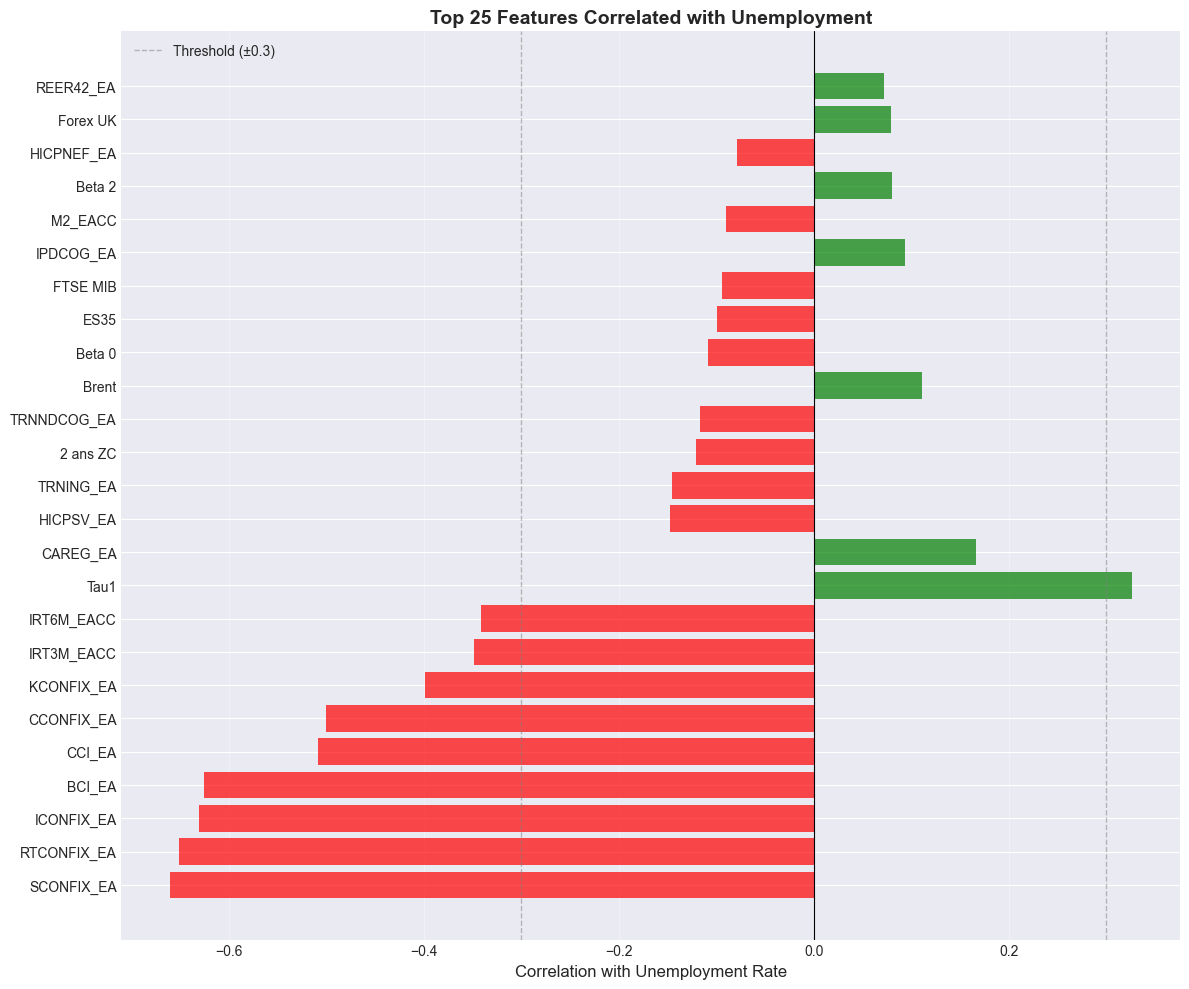


Features with |correlation| >= 0.3: 10


In [33]:
# Calculate correlations with unemployment rate
feature_cols = [col for col in df_final.columns if col not in ['UNETOT_EA']]
correlations = {}

for col in feature_cols:
    valid_mask = df_final[col].notna() & df_final['UNETOT_EA'].notna()
    if valid_mask.sum() > 10:
        corr = df_final.loc[valid_mask, col].corr(df_final.loc[valid_mask, 'UNETOT_EA'])
        correlations[col] = corr

corr_df = pd.DataFrame({
    'Feature': list(correlations.keys()),
    'Correlation': list(correlations.values())
}).sort_values('Correlation', key=abs, ascending=False)

# Visualize correlations
fig, ax = plt.subplots(figsize=(12, 10))
top_corr = corr_df.head(25)
colors = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'])
ax.set_xlabel('Correlation with Unemployment Rate', fontsize=12)
ax.set_title('Top 25 Features Correlated with Unemployment', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (±0.3)')
ax.axvline(x=-0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Count features above threshold
threshold = 0.3
selected = corr_df[abs(corr_df['Correlation']) >= threshold]
print(f"\nFeatures with |correlation| >= {threshold}: {len(selected)}")

Plotting horizon h=3


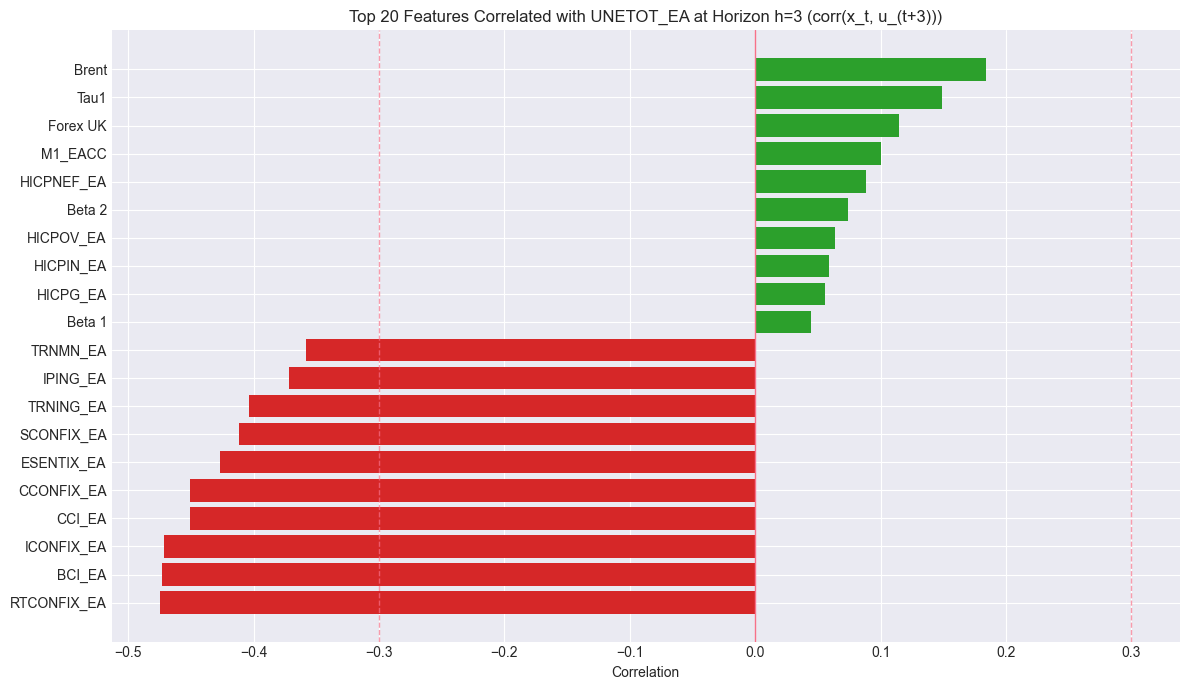

Plotting horizon h=6


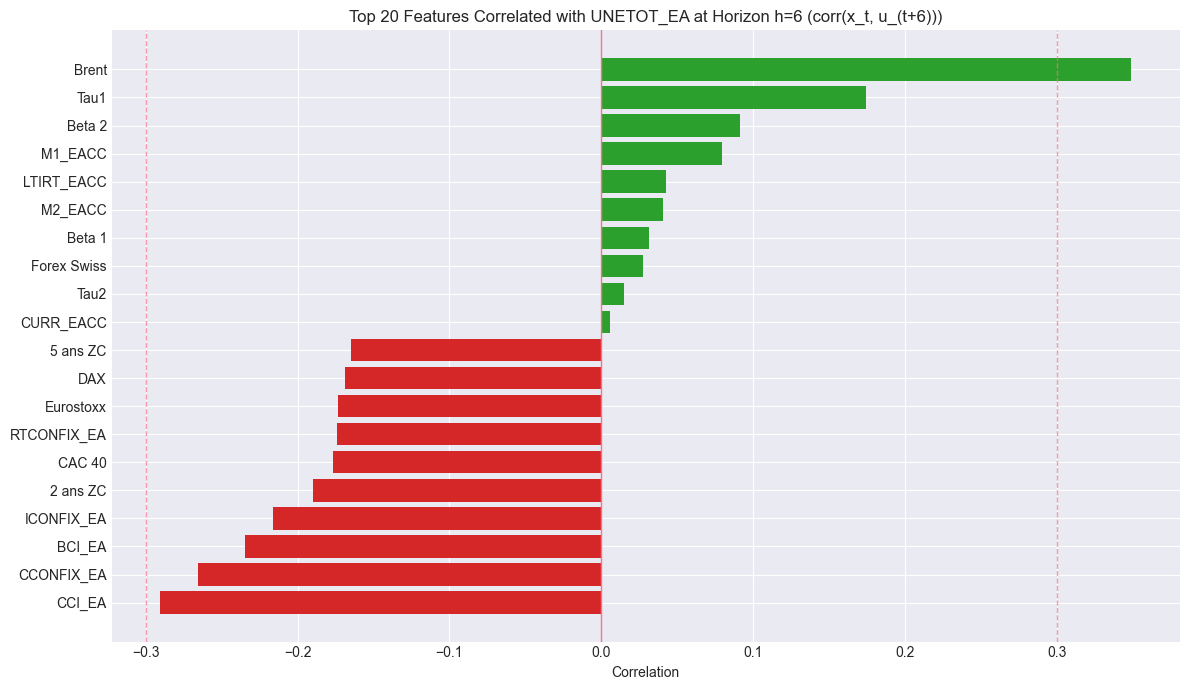

In [34]:
target_col = "UNETOT_EA"  
horizons = [3, 6]
top_n = 20

if target_col not in df_final.columns:
    raise ValueError(
        f"'{target_col}' not found in df_final columns.\n"
        f"Available columns (first 30): {list(df_final.columns)[:30]}"
    )

for h in horizons:
    print(f"Plotting horizon h={h}")
    corrs_h = lead_corr(df_final, target=target_col, h=h)
    plot_top_corrs(
        corrs_h,
        title=f"Top {top_n} Features Correlated with {target_col} at Horizon h={h} (corr(x_t, u_(t+{h})))",
        top_n=top_n,
        threshold=0.3
    )

Confidence indicators, stock market indices, and medium-term interest rates are negatively correlated with future changes in unemployment: increases in these variables are associated with decreases in the unemployment rate at horizons of 3 and 6 months.

## 3. Expectation Maximization and PCA

Since the dataset has missing values, we estimate factors using PCA but with the EM algorithm to allow for missing values to be dynamically replaced by estimated values. 

In [35]:
y = df_final["UNETOT_EA"]
X = df_final.drop(columns=["UNETOT_EA"])

First, we compute factors using PCA. Missing values are handled via the EM algorithm.

In [36]:
empca = EM_PCA(
    kmax=10,
    criterion="IC2",
    demean=2,
    max_iter=50,
    tol=1e-6,
    fallback_n_factors=3,
    verbose=False,
)

result = empca.fit(X)

factors = result.factors            # pd.DataFrame (T × r)
loadings = result.loadings          # pd.DataFrame (N × r)
imputed_data = result.imputed_data  # pd.DataFrame (T × N)
r2_by_var = result.r2_by_variable   # pd.Series (N,)

print("Factors extracted:")
print(f"  - Number of factors : {result.n_factors}")
print(f"  - Total variance explained : {result.variance_explained:.2%}")
print(f"  - Convergence in {result.n_iterations} iterations")
print("\n" + "=" * 70)
print("FACTOR INTERPRETATION")
print("=" * 70)

for i in range(result.n_factors):
    factor_name = f"F{i+1}"
    print(f"\n{factor_name} - Top 10 loadings (absolute value):")
    top_loadings = loadings[factor_name].abs().nlargest(10)
    for var, loading in top_loadings.items():
        sign = "+" if loadings.loc[var, factor_name] > 0 else "-"
        print(f"  {sign} {var:30s} : {abs(loading):.3f}")

print("\nR2 distribution:")
print(r2_by_var.describe())
print("\nVariables best explained (R2 > 0.7):")
print(r2_by_var[r2_by_var > 0.7].sort_values(ascending=False))

CT pour r=1: 0.085019
CT pour r=10: 0.850192
Factors extracted:
  - Number of factors : 10
  - Total variance explained : 67.91%
  - Convergence in 14 iterations

FACTOR INTERPRETATION

F1 - Top 10 loadings (absolute value):
  + TRNMN_EA                       : 2.316
  + IPMN_EA                        : 2.257
  + TRNING_EA                      : 2.215
  + IPING_EA                       : 2.144
  + TRNCAG_EA                      : 2.144
  + TRNDCOG_EA                     : 2.130
  + IPDCOG_EA                      : 2.110
  + IPCAG_EA                       : 2.040
  + ESENTIX_EA                     : 1.828
  + IPCOG_EA                       : 1.687

F2 - Top 10 loadings (absolute value):
  + ICONFIX_EA                     : 2.702
  + BCI_EA                         : 2.700
  + SCONFIX_EA                     : 2.690
  + RTCONFIX_EA                    : 2.627
  + KCONFIX_EA                     : 2.136
  + CCONFIX_EA                     : 1.971
  + CCI_EA                         : 1.968
  - 

Second, we regress those factors on the unemployment rate (stationarised) in order to get the coefficients we will use for our index. Regression is done on a rolling basis:
$$
\Delta u_t = \alpha + \beta' F_t + \varepsilon_t
$$

In [37]:
# ==================== ALIGNMENT y / factors ====================
if isinstance(y, np.ndarray):
    y_series = pd.Series(y, index=X.index, name="y")
else:
    y_series = y.rename("y") if isinstance(y, pd.Series) else pd.Series(y, index=X.index, name="y")

df_reg = pd.concat([y_series, factors], axis=1).dropna()
y_aligned = df_reg["y"]
F_aligned = df_reg[factors.columns]

print("\n" + "=" * 70)
print("DFM REGRESSION (Rolling OLS, 36 months)")
print("=" * 70)

print(f"Aligned data: T={len(df_reg)}, r={F_aligned.shape[1]}")

# ==================== ROLLING OLS ====================

window = 36  # 3 years

# Instantiate and fit
roll_reg = RollingRegression(y=y_aligned, X=F_aligned, window=window)
roll_result = roll_reg.fit()

# Extract results
betas_rolling = roll_result.betas
alpha_rolling = roll_result.alpha
indicator_raw_rolling = roll_result.fitted
r2_rolling = roll_result.r2
dates_rolling = roll_result.dates

print(f"Rolling regression done.")
print(f"  - Window: {window} months")
print(f"  - OOS points: {len(indicator_raw_rolling)}")
print(f"  - Mean R² (train): {r2_rolling.mean():.3f}")
print(f"  - Last rolling betas:\n{betas_rolling.tail(1).T}")


DFM REGRESSION (Rolling OLS, 36 months)
Aligned data: T=244, r=10
Rolling regression done.
  - Window: 36 months
  - OOS points: 208
  - Mean R² (train): 0.499
  - Last rolling betas:
     2025-01-01
F1      -0.0756
F2      -0.1086
F3       0.0197
F4      -0.0071
F5      -0.0315
F6      -0.0745
F7      -0.0433
F8      -0.0364
F9       0.0487
F10     -0.0421


Third, we extract the index as:
$$
Index_t = -\beta'F_t
$$
(minus because we want it to go up when economy is booming; however unemployment should go down at those times). Then we normalize it so that above 50 = boom, below = contraction. (à voir si on modif)

In [38]:
indicator_raw_rolling = -indicator_raw_rolling
# ==================== INDICATOR CONSTRUCTION (PMI-like) ====================
print("\n" + "=" * 70)
print("INDICATOR CONSTRUCTION (Rolling betas)")
print("=" * 70)

mean_ref = indicator_raw_rolling.mean()
std_ref = indicator_raw_rolling.std(ddof=1)

indicator_pmi_rolling = 50 + 10 * (indicator_raw_rolling - mean_ref) / std_ref
indicator_pmi_rolling.name = "Indicator"

df_indicator = pd.DataFrame(
    {
        "Indicator": indicator_pmi_rolling,
        "Unemployment_change": y_aligned.reindex(indicator_pmi_rolling.index),
    },
    index=indicator_pmi_rolling.index,
)

print(f"  Mean: 50.0")
print(f"  Std: 10.0")
print(f"  Current value: {df_indicator['Indicator'].iloc[-1]:.1f}")
print(f"  Min: {df_indicator['Indicator'].min():.1f}, Max: {df_indicator['Indicator'].max():.1f}")


INDICATOR CONSTRUCTION (Rolling betas)
  Mean: 50.0
  Std: 10.0
  Current value: 49.2
  Min: 7.6, Max: 76.1



VISUALIZATIONS


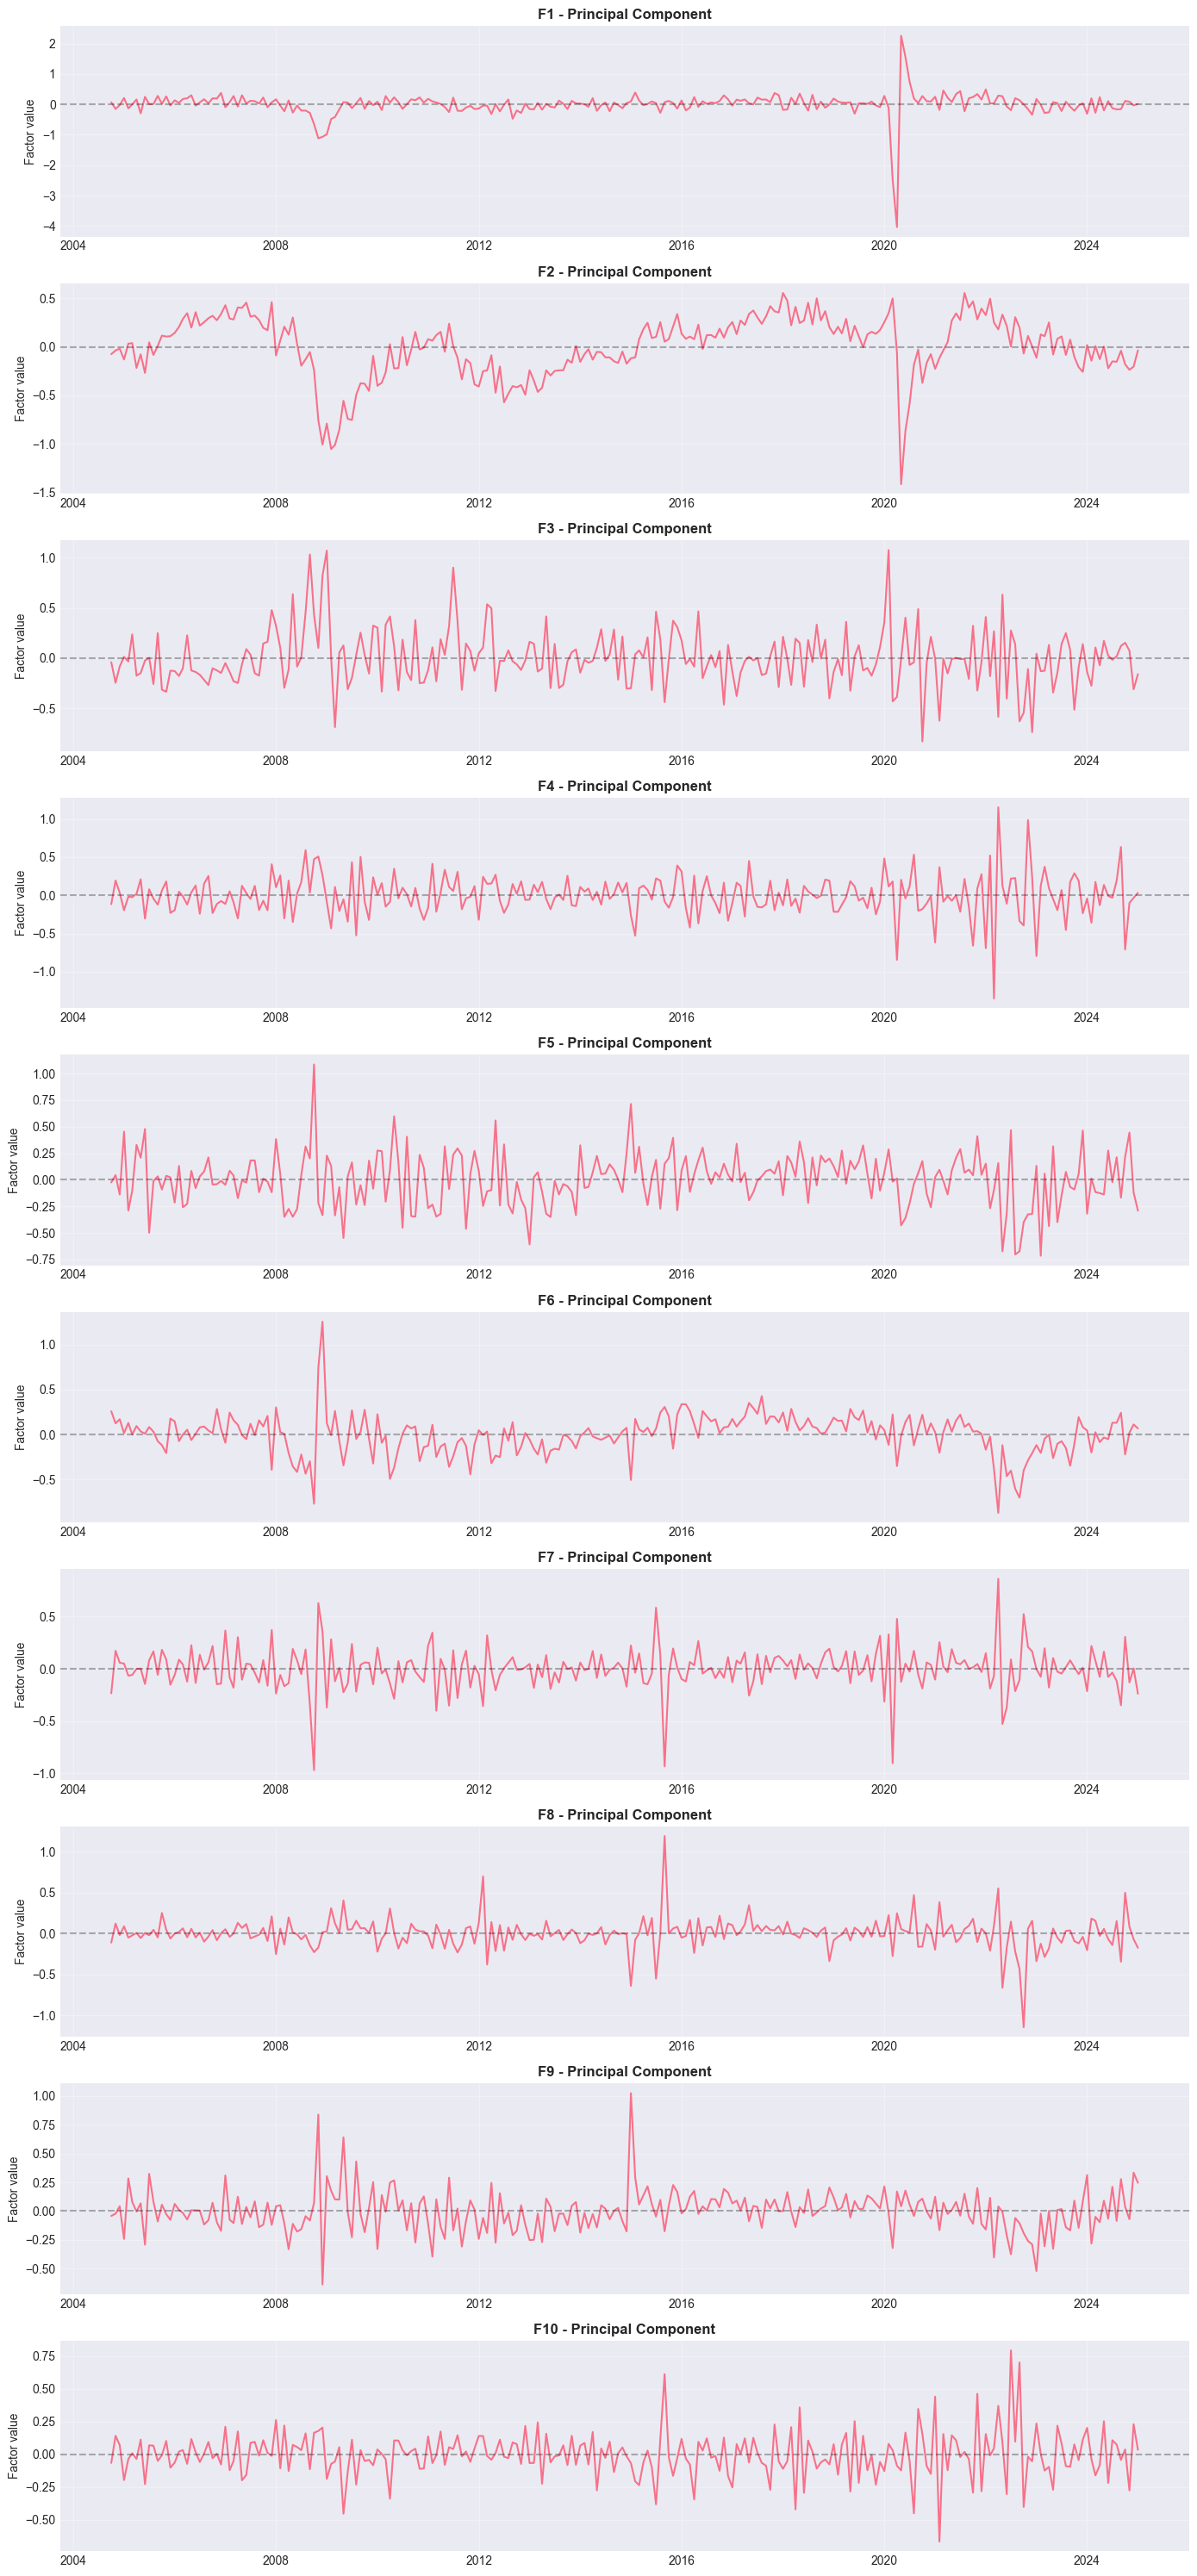

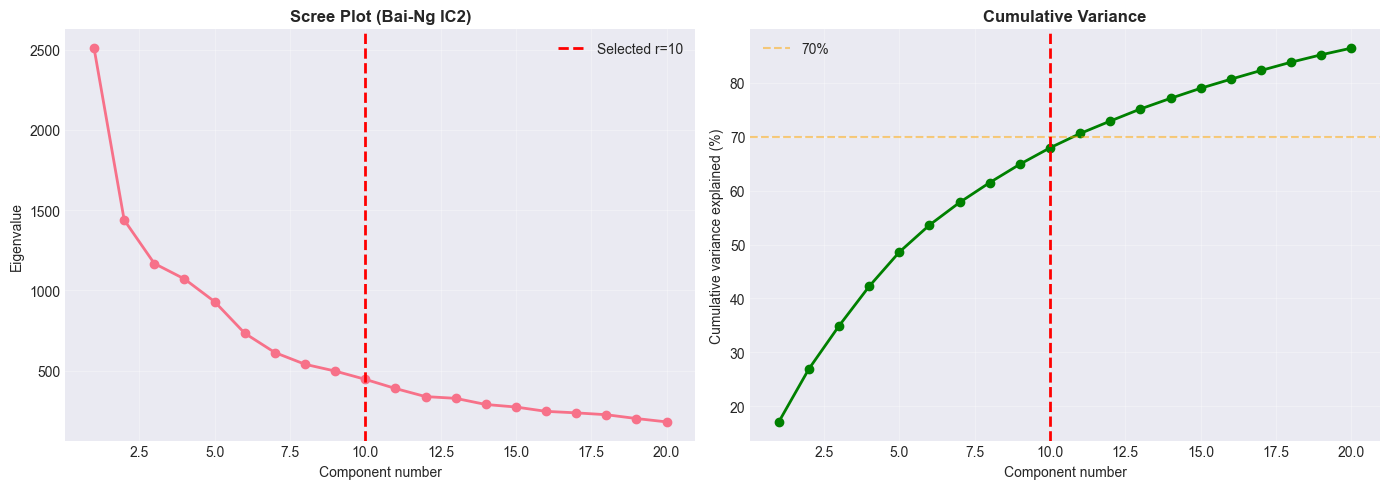

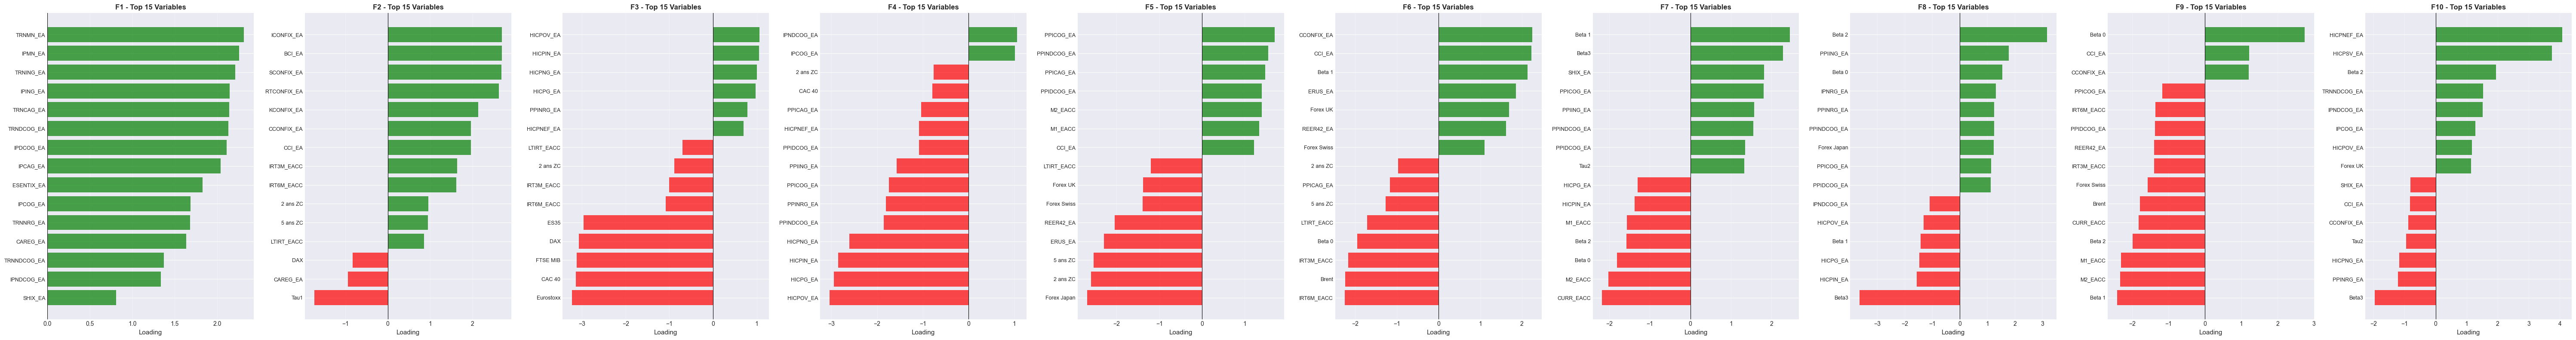

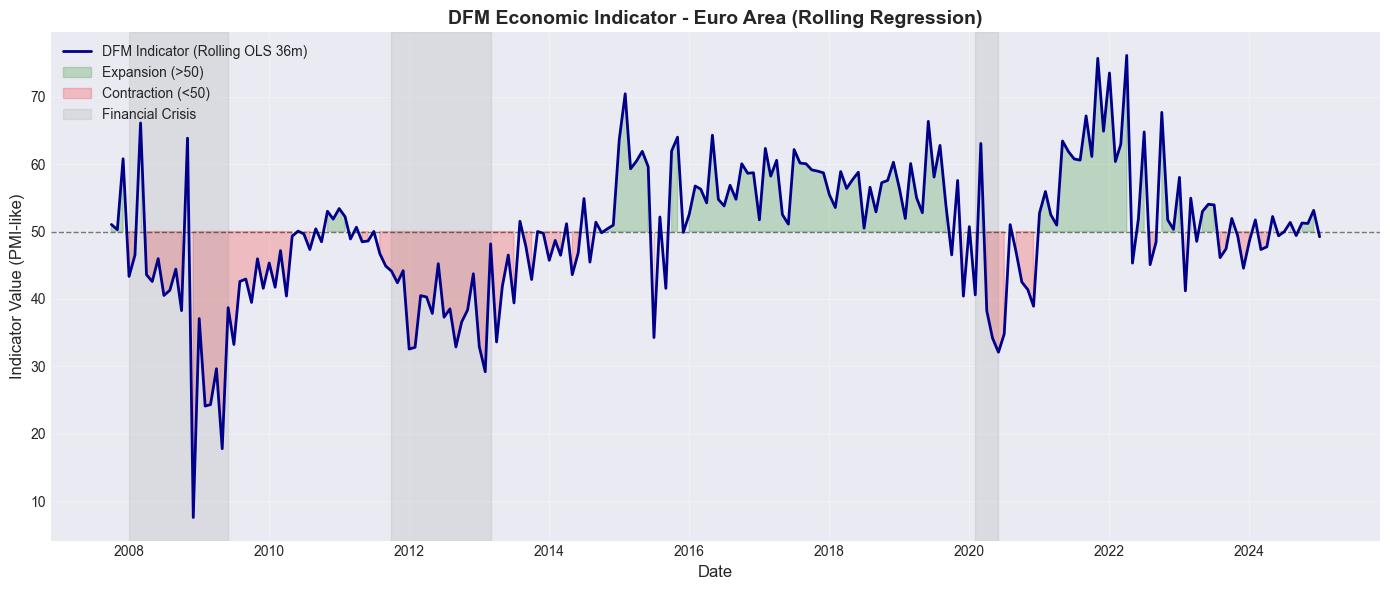

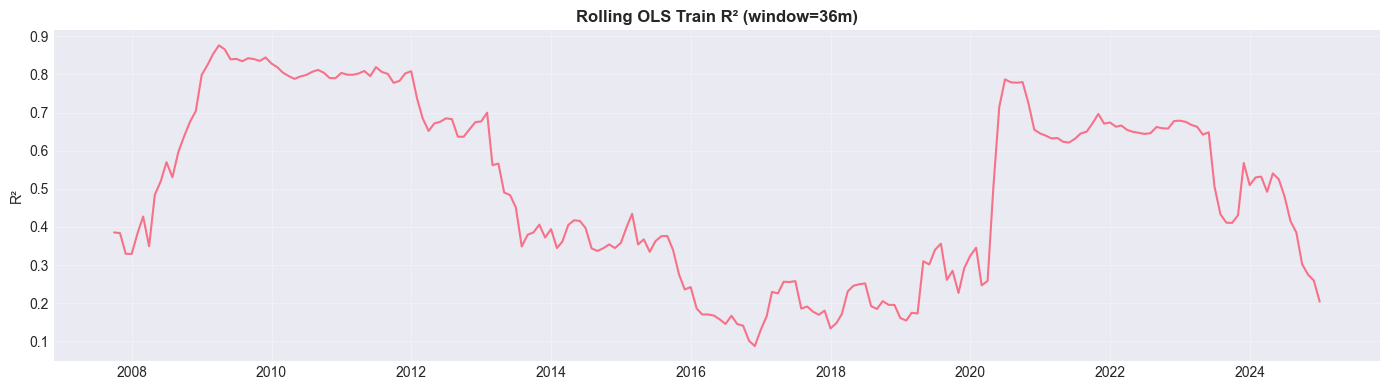

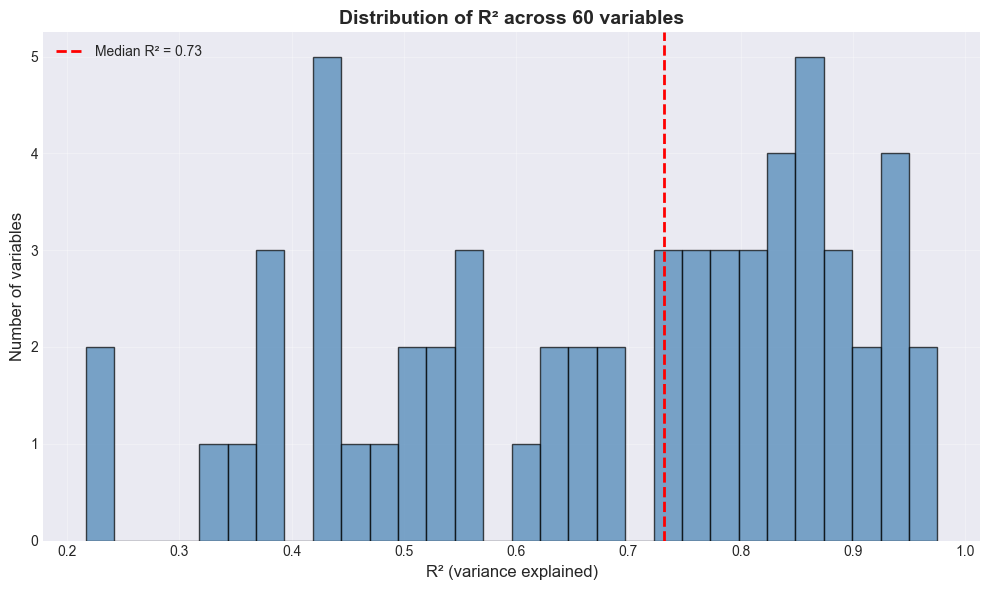

In [39]:
# ==================== VISUALISATIONS ====================

print("\n" + "=" * 70)
print("VISUALIZATIONS")
print("=" * 70)

# 6.1 Factors
fig, axes = plt.subplots(result.n_factors, 1, figsize=(14, 3 * result.n_factors))
if result.n_factors == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    factor_name = f"F{i+1}"
    ax.plot(factors.index, factors[factor_name], linewidth=1.5)
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.set_title(f"{factor_name} - Principal Component", fontsize=12, fontweight="bold")
    ax.set_ylabel("Factor value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6.2 Scree plot (eigenvalues) + cumulative variance
eigenvalues = result.eigenvalues
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, min(20, len(eigenvalues)) + 1), eigenvalues[:20], "o-", linewidth=2)
ax1.axvline(result.n_factors, color="r", linestyle="--", linewidth=2, label=f"Selected r={result.n_factors}")
ax1.set_xlabel("Component number")
ax1.set_ylabel("Eigenvalue")
ax1.set_title("Scree Plot (Bai-Ng IC2)", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

cumvar = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
ax2.plot(range(1, min(20, len(cumvar)) + 1), cumvar[:20], "o-", linewidth=2, color="green")
ax2.axhline(70, color="orange", linestyle="--", alpha=0.5, label="70%")
ax2.axvline(result.n_factors, color="r", linestyle="--", linewidth=2)
ax2.set_xlabel("Component number")
ax2.set_ylabel("Cumulative variance explained (%)")
ax2.set_title("Cumulative Variance", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6.3 Loadings
fig, axes = plt.subplots(1, result.n_factors, figsize=(6 * result.n_factors, 8))
if result.n_factors == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    factor_name = f"F{i+1}"
    top_vars = loadings[factor_name].abs().nlargest(15)
    top_loadings = loadings.loc[top_vars.index, factor_name].sort_values()
    colors = ["green" if x > 0 else "red" for x in top_loadings]
    ax.barh(range(len(top_loadings)), top_loadings.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_loadings)))
    ax.set_yticklabels(top_loadings.index, fontsize=9)
    ax.set_xlabel("Loading", fontsize=11)
    ax.set_title(f"{factor_name} - Top 15 Variables", fontsize=12, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# 6.4 Index (Rolling)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_indicator.index,
    df_indicator["Indicator"],
    linewidth=2,
    label=f"DFM Indicator (Rolling OLS {window}m)",
    color="darkblue",
)
ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5)

ax.fill_between(
    df_indicator.index,
    50,
    df_indicator["Indicator"],
    where=(df_indicator["Indicator"] > 50),
    alpha=0.2,
    color="green",
    label="Expansion (>50)",
)
ax.fill_between(
    df_indicator.index,
    50,
    df_indicator["Indicator"],
    where=(df_indicator["Indicator"] < 50),
    alpha=0.2,
    color="red",
    label="Contraction (<50)",
)

recessions = [
    ("2008-01", "2009-06", "Financial Crisis"),
    ("2011-10", "2013-03", "Sovereign Debt"),
    ("2020-02", "2020-06", "COVID-19"),
]
for start, end, label in recessions:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.15,
        color="gray",
        label=label if recessions[0] == (start, end, label) else "",
    )

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Indicator Value (PMI-like)", fontsize=12)
ax.set_title("DFM Economic Indicator - Euro Area (Rolling Regression)", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6.4bis Rolling R² (train window) optional diagnostic
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(r2_rolling.index, r2_rolling.values, linewidth=1.5)
ax.set_title(f"Rolling OLS Train R² (window={window}m)", fontweight="bold")
ax.set_ylabel("R²")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6.5 R2 distribution (EM-PCA variable-wise)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(r2_by_var.dropna(), bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(
    r2_by_var.median(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median R² = {r2_by_var.median():.2f}",
)
ax.set_xlabel("R² (variance explained)", fontsize=12)
ax.set_ylabel("Number of variables", fontsize=12)
ax.set_title(f"Distribution of R² across {len(r2_by_var)} variables", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()